In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from paddleocr import PaddleOCR

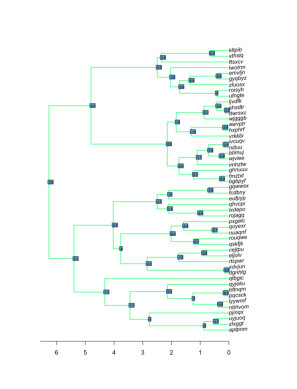

In [33]:
img_path = "dev/_datasets/Tree_PNG_50tips_NOISE_1/images/Tree_50_1.png"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [85]:
ocr = PaddleOCR(lang="en", use_doc_unwarping=False)
results = ocr.predict(image)

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dorian\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dorian\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dorian\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


In [86]:
print(result[0])

{'input_path': None, 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 180, 'rot_img': array([[[  0, ...,   0],
        ...,
        [  0, ...,   0]],

       ...,

       [[  0, ...,   0],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8), 'output_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8)}, 'dt_polys': [array([[653,  34],
       ...,
       [653,  80]], shape=(4, 2), dtype=int16), array([[840,  31],
       ...,
       [840,  79]], shape=(4, 2), dtype=int16), array([[1017,   33],
       ...,
       [1017

In [87]:
for res in result:
    res.save_to_img("dev/_notebooks/label-extraction-paddleocr-outputs")

In [88]:
outputs = []

for line in results:
    rec_polys = line.get("rec_polys", [])
    rec_boxes = line.get("rec_boxes", [])
    rec_texts = line.get("rec_texts", [])
    rec_scores = line.get("rec_scores", [])

    for i, poly in enumerate(rec_polys):
        outputs.append({
            "polygon": rec_polys[i],
            "bbox": rec_boxes[i],
            "text": rec_texts[i],
            "score": rec_scores[i]
        })

In [89]:
print(outputs)

[{'polygon': array([[1175,  202],
       ...,
       [1177,  241]], shape=(4, 2), dtype=int16), 'bbox': array([1175, ...,  241], shape=(4,), dtype=int16), 'text': 'kltpib', 'score': 0.9328272938728333}, {'polygon': array([[1072,  224],
       ...,
       [1072,  253]], shape=(4, 2), dtype=int16), 'bbox': array([1072, ...,  253], shape=(4,), dtype=int16), 'text': '6.3', 'score': 0.9973090291023254}, {'polygon': array([[1175,  233],
       ...,
       [1177,  272]], shape=(4, 2), dtype=int16), 'bbox': array([1175, ...,  272], shape=(4,), dtype=int16), 'text': 'xthslq', 'score': 0.994307816028595}, {'polygon': array([[808, 246],
       ...,
       [808, 276]], shape=(4, 2), dtype=int16), 'bbox': array([808, ..., 276], shape=(4,), dtype=int16), 'text': '2.9', 'score': 0.8663812279701233}, {'polygon': array([[1176,  269],
       ...,
       [1178,  302]], shape=(4, 2), dtype=int16), 'bbox': array([1176, ...,  302], shape=(4,), dtype=int16), 'text': 'ftsxcv', 'score': 0.9887886643409729}, {'

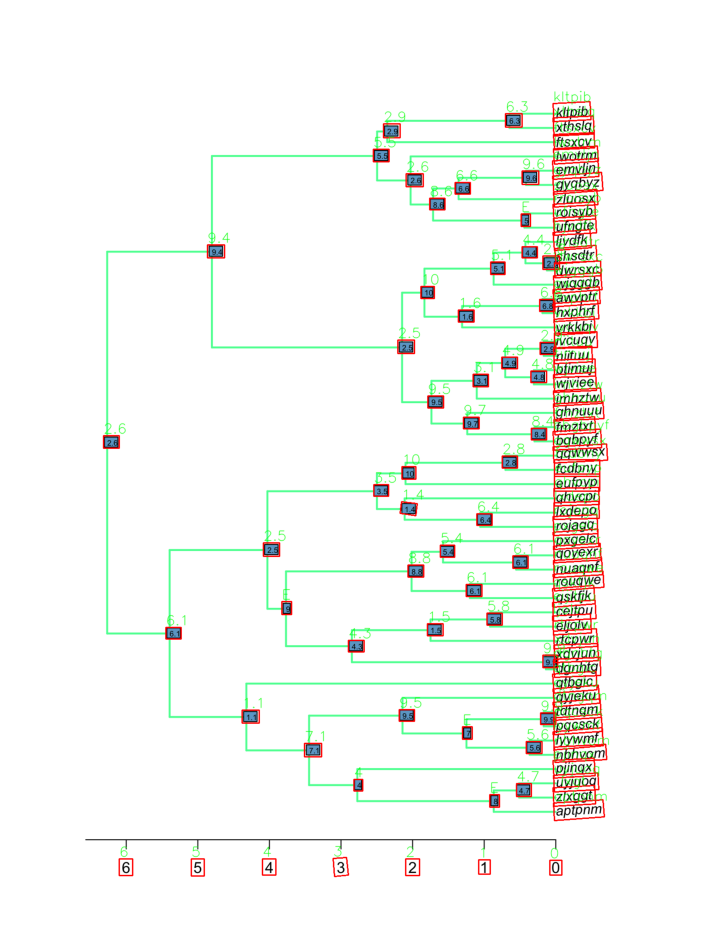

In [99]:
plt.figure(figsize=(12, 12))
img_show = image.copy()
for item in outputs:
    poly = np.array(item["polygon"], dtype=np.int32)

    #poly[:, 0] = img_show.shape[1] - poly[:, 0]
    #poly[:, 1] = img_show.shape[0] - poly[:, 1]

    text = item["text"]
    cv2.polylines(img_show, [poly], True, (255, 0, 0), 2)
    x, y = poly[0]
    cv2.putText(img_show, text, (int(x), int(y) - 5), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
plt.imshow(img_show)
plt.axis("off")
plt.show()

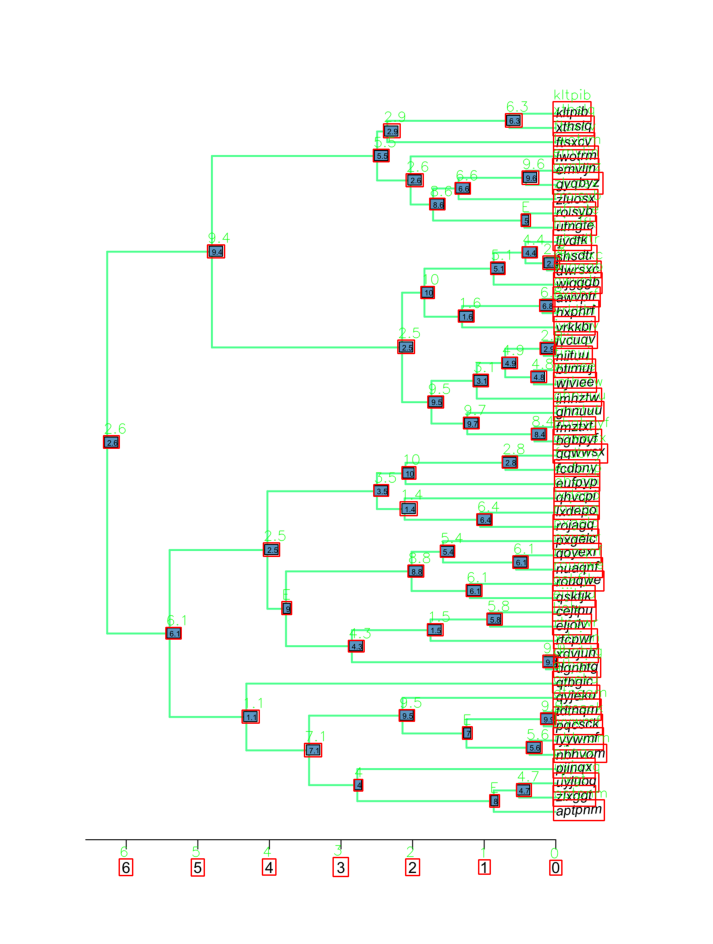

In [100]:
plt.figure(figsize=(12, 12))
img_show = image.copy()
for item in outputs:
    x1, y1, x2, y2 = item["bbox"]; text = item["text"]

    #x1, x2 = img_show.shape[1] - x1, img_show.shape[1] - x2
    #y1, y2 = img_show.shape[0] - y1, img_show.shape[0] - y2

    cv2.rectangle(img_show, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(img_show, text, (x1, max(y1 - 5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
plt.imshow(img_show)
plt.axis("off")
plt.show()

In [101]:
filtered_text_boxes = [
    {"bbox": item["bbox"], "text": item["text"], "score": item["score"]}
    for item in outputs
    if not any(char.isdigit() for char in item["text"])
]

for i, entry in enumerate(filtered_text_boxes[:20], 1):
    print(f"{i}: text='{entry['text']}', score={entry['score']:.2f}, bbox={entry['bbox']}")

1: text='kltpib', score=0.93, bbox=[1175 ...  241]
2: text='xthslq', score=0.99, bbox=[1175 ...  272]
3: text='ftsxcv', score=0.99, bbox=[1176 ...  302]
4: text='Iwotrm', score=0.96, bbox=[1176 ...  333]
5: text='emvljn', score=0.82, bbox=[1174 ...  366]
6: text='gyqbyz', score=1.00, bbox=[1174 ...  398]
7: text='zluosx', score=1.00, bbox=[1176 ...  426]
8: text='rroisyb', score=0.92, bbox=[1175 ...  457]
9: text='E', score=0.90, bbox=[1106 ...  468]
10: text='ufngte', score=1.00, bbox=[1176 ...  487]
11: text='hjvdfk', score=0.74, bbox=[1175 ...  520]
12: text='shsdtr', score=1.00, bbox=[1179 ...  549]
13: text='dwrsxc', score=1.00, bbox=[1178 ...  579]
14: text='wjgggb', score=0.97, bbox=[1176 ...  613]
15: text='awvptr', score=0.83, bbox=[1175 ...  642]
16: text='hxphrf', score=0.95, bbox=[1175 ...  674]
17: text='vrkkbi', score=1.00, bbox=[1177 ...  703]
18: text='ivcuqv', score=0.99, bbox=[1178 ...  732]
19: text='niituu', score=1.00, bbox=[1176 ...  765]
20: text='timuj', score=0